In [ ]:
using LinearAlgebra
using BSplineKit
using PyCall
using DelimitedFiles
using Plots
using NonlinearEigenproblems
include("BaseFlow_cavity.jl")

In [ ]:
Res = 2000
N_cheb = 129
mode = 1
Ro = - 1.0
Co = 2 - Ro - Ro^2
Ts = 0
u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts,mode)
D,D2,z = CRC_BF.Cheb(N_cheb,mode)
F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,mode)

In [349]:
R = 160
n = 0
be = -0.1
OMEGA = 8.0
omega = OMEGA/R
c = 0.5
cof = Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega,R)
L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
nep = PEP([L0,L1,L2]);
eigval,eigvec = iar(nep, σ = c, neigs = 3 ,maxit = 500 , tol=1e-12)
vel = eig_full(eigvec,N_cheb,3)
@show eigval

eigval = ComplexF64[0.38692291065471657 + 0.018839141082758876im, 0.3419292183883702 - 0.17535830124491822im, 0.24880113128242137 - 0.08101029285257831im]


3-element Vector{ComplexF64}:
 0.38692291065471657 + 0.018839141082758876im
  0.3419292183883702 - 0.17535830124491822im
 0.24880113128242137 - 0.08101029285257831im

In [ ]:
scatter(real(eigval),imag(eigval))

In [348]:
writedlm("eigval_scatter.dat", [real(eigval) imag(eigval)])

In [ ]:
0.17364604233982012 + 0.6086072614951381im
0.34192921838843854 - 0.17535830124494683im

In [350]:
vel = eig_full(eigvec,N_cheb,1)
eigval[1]

0.38692291065471657 + 0.018839141082758876im

In [ ]:
eigvec_bode = [vel[1] vel[2] vel[3] vel[4]]

In [ ]:
eigvec_bode = eigvec_bode ./ maximum(abs.(eigvec_bode))

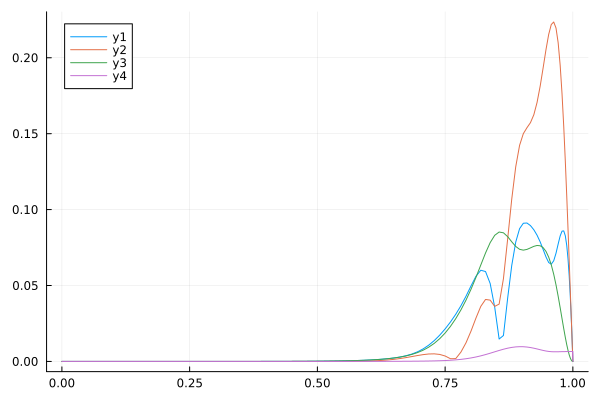

In [351]:
plot(z,abs.(vel[1]))
plot!(z,abs.(vel[2]))
plot!(z,abs.(vel[3]))
plot!(z,abs.(vel[4]))

In [ ]:
writedlm("eigval.dat", [z abs.(eigvec_von) abs.(eigvec_bode)])

In [ ]:
R = 50
n = 10
be = -0.1
# OMEGA = 0.0
# omega = OMEGA/R
c = 0.3
cof = Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
H0,H1 = assemble_time_mat(cof,D,D2,be,omega,R,N_cheb)
val = eigen(H0,H1).values
val_1 = filter(x-> abs(imag(x)) < 0.1 , val)
scatter(real(val_1),imag(val_1))

In [ ]:
n = 30
OMEGA = 4.0
open("growthrate_$(OMEGA)_$(n).dat","w") do io
    c = 0.8
    for R = 200 : 2 : 600
        omega = OMEGA/R
        be =  n/R
        cof = Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
        L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega,R)
        L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
        nep = PEP([L0,L1,L2]);
        eigval,eigvec = iar(nep, σ = c, neigs = 1,maxit = 500 , tol=1e-14)
        c = eigval[1]
        writedlm(io,[R be real(eigval[1]) imag(eigval[1])])
        flush(io)
    end
end

In [ ]:
n = 30
OMEGA=4.0
data = readdlm("growthrate_$(OMEGA)_$(n).dat")
R   = data[:, 1]
ai  = data[:, 4]
dai_dR    = Base.diff(ai) ./ Base.diff(R)
d2ai_dR2  = Base.diff(dai_dR) ./ Base.diff(R)[2:end]

In [ ]:
plot(R[2:end],dai_dR)

In [ ]:
alpha = 0.42570837021618757  
H0,H1 = assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
val = eigen(H0,H1).values
val = filter(!isnan,val)
omega_differ = 0.0/R
target_mode = findmin(abs.(val.- omega_differ))
val_target = val[target_mode[2]]

In [ ]:
plot(z,abs.(vel_A[1]))
plot!(z,abs.(vel_A[2]))
plot!(z,abs.(vel_A[3]))

In [ ]:
plot(z,(F))
plot!(z,(G))
plot!(z,(H))

In [ ]:
struct COF
        Ta :: Matrix{ComplexF64}
        A :: Matrix{ComplexF64}
        B :: Matrix{ComplexF64}
        C :: Matrix{ComplexF64}
        dC :: Matrix{ComplexF64}
        D1 :: Matrix{ComplexF64}
        Vxx :: Matrix{ComplexF64}
        Vyy :: Matrix{ComplexF64}
        Vzz :: Matrix{ComplexF64}
        dVzz :: Matrix{ComplexF64}
        d2Vzz :: Matrix{ComplexF64}
        Vxy :: Matrix{ComplexF64}
        Vxz :: Matrix{ComplexF64}
        dVxz :: Matrix{ComplexF64}
        Vyz :: Matrix{ComplexF64}
        dVyz :: Matrix{ComplexF64}
end
function Spatial_mode_BEK1(F,G,H,R,N_cheb,D,D2,Res)
    Res0 = sqrt(Res)
    size = N_cheb + 1
    eye = I(N_cheb+1)
    Zero = zeros(N_cheb+1,N_cheb+1)
    Ta = zeros(4*size,4*size)
    A = zeros(4*size,4*size)
    B = zeros(4*size,4*size)
    C = zeros(4*size,4*size)
    D1 = zeros(4*size,4*size)
    Vxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)
    Vxx = zeros(4*size,4*size)
    Vyy = zeros(4*size,4*size)
    Vzz = zeros(4*size,4*size)
    dVxz = zeros(4*size,4*size)
    dVyz = zeros(4*size,4*size)
    Ta_11 = eye
    Ta_12 = Ta_13 = Ta_14 = Zero
    Ta_22 = eye
    Ta_21 = Ta_23 = Ta_24 = Zero
    Ta_33 = eye
    Ta_31 = Ta_32 = Ta_34 = Zero
    Ta_41 = Ta_42 = Ta_43 = Ta_44 = Zero

    A_11 = F .* eye
    A_12 = A_13 = Zero
    A_14 = eye
    A_22 = F .* eye
    A_21 = A_23 = A_24 = Zero
    A_31 = A_32 = A_34 = Zero
    A_33 = F .* eye
    A_41 = (1) .* eye
    A_42 = A_43 = A_44 = Zero

    B_11 = (1/R) * G .* eye
    B_12 = B_13 = B_14 = Zero
    B_21 = B_23 = Zero
    B_22 = (1/R) * G .* eye
    B_24 = (1/R) .* eye
    B_31 = B_32 = B_34 = Zero
    B_33 = (1/R) * G .* eye
    B_41 = B_43 = B_44 = Zero
    B_42 = (1/R) .* eye

    C_11 = (1/(R*Res0)) * H .* eye
    dC_11 = D * diag(C_11) .* eye
    C_12 = C_13 = C_14 = Zero
    dC_12 = dC_13 = dC_14 = Zero
    C_22 = (1/(R*Res0)) * H .* eye
    dC_22 = D * diag(C_22) .* eye
    C_21 = C_23 = C_24 = Zero
    dC_21 = dC_23 = dC_24 = Zero
    C_31 = C_32 = Zero
    dC_31 = dC_32 = Zero
    C_33 = (1/(R*Res0)) * H .* eye
    dC_33 = D * diag(C_33) .* eye
    C_34 = 1/Res0 * eye
    dC_34 = D * diag(C_34) .* eye
    C_41 = C_42 = C_44 = Zero
    dC_41 = dC_42 = dC_44 = Zero
    C_43 = (1/Res0) * eye
    dC_43 = D * diag(C_43) .* eye

    D_11 = (1/R) * F .* eye
    D_12 = -(1/R) * 2 * (G.+1) .* eye
    D_13 = 1/Res0 * D * F .* eye
    D_14 = Zero
    D_21 = (1/R) * 2 * (G.+1) .* eye
    D_22 = (1/R) * F .* eye
    D_23 = 1/Res0 * D * G .* eye
    D_24 = Zero
    D_31 = D_32 = D_34 = Zero
    D_33 = (1/(R*Res0)) * D*H.* eye
    D_41 = 1/R .* eye
    D_42 = D_43 = D_44 = Zero

    Vxx_11 = -(1/R) * eye
    Vxx_12 = Vxx_13 = Vxx_14 = Zero
    Vxx_22 = -(1/R) * eye
    Vxx_21 = Vxx_23 = Vxx_24 = Zero
    Vxx_33 = -(1/R) * eye
    Vxx_31 = Vxx_32 = Vxx_34 = Zero
    Vxx_41 = Vxx_42 = Vxx_43 = Vxx_44 = Zero

    Vyy_11 = -(1/R^3) * eye
    Vyy_12 = Vyy_13 = Vyy_14 = Zero
    Vyy_22 = -(1/R^3) * eye
    Vyy_21 = Vyy_23 = Vyy_24 = Zero
    Vyy_33 = -(1/R^3) * eye
    Vyy_31 = Vyy_32 = Vyy_34 = Zero
    Vyy_41 = Vyy_42 = Vyy_43 = Vyy_44 = Zero

    Vzz_11 = -(1/(R*Res)) * eye
    dVzz_11 = D * diag(Vzz_11) .* eye
    d2Vzz_11 = D2 * diag(Vzz_11) .* eye
    Vzz_12 = Vzz_13 = Vzz_14 = Zero
    dVzz_12 = dVzz_13 = dVzz_14 = Zero
    d2Vzz_12 = d2Vzz_13 = d2Vzz_14 = Zero
    Vzz_22 =  -(1/(R*Res)) * eye
    dVzz_22 = D * diag(Vzz_22) .* eye
    d2Vzz_22 = D2 * diag(Vzz_22) .* eye
    Vzz_21 = Vzz_23 = Vzz_24 = Zero
    dVzz_21 = dVzz_23 = dVzz_24 = Zero
    d2Vzz_21 = d2Vzz_23 = d2Vzz_24 = Zero
    Vzz_33 =  -(1/(R*Res)) * eye
    dVzz_33 = D * diag(Vzz_33) .* eye
    d2Vzz_33 = D2 * diag(Vzz_33) .* eye
    Vzz_31 = Vzz_32 = Vzz_34 = Zero
    dVzz_31 = dVzz_32 = dVzz_34 = Zero
    d2Vzz_31 = d2Vzz_32 = d2Vzz_34 = Zero
    Vzz_41 = Vzz_42 = Vzz_43 = Vzz_44 = Zero
    dVzz_41 = dVzz_42 = dVzz_43 = dVzz_44 = Zero
    d2Vzz_41 = d2Vzz_42 = d2Vzz_43 = d2Vzz_44 = Zero

    Vxy = zeros(4*size,4*size)
    dVxy = zeros(4*size,4*size)
    Vxz = zeros(4*size,4*size)
    Vyz = zeros(4*size,4*size)

    Ta = [Ta_11 Ta_12 Ta_13 Ta_14;Ta_21 Ta_22 Ta_23 Ta_24;Ta_31 Ta_32 Ta_33 Ta_34;Ta_41 Ta_42 Ta_43 Ta_44]
    A = [A_11 A_12 A_13 A_14;A_21 A_22 A_23 A_24;A_31 A_32 A_33 A_34;A_41 A_42 A_43 A_44]
    B = [B_11 B_12 B_13 B_14;B_21 B_22 B_23 B_24;B_31 B_32 B_33 B_34;B_41 B_42 B_43 B_44]
    C = [C_11 C_12 C_13 C_14;C_21 C_22 C_23 C_24;C_31 C_32 C_33 C_34;C_41 C_42 C_43 C_44]
    dC = [dC_11 dC_12 dC_13 dC_14;dC_21 dC_22 dC_23 dC_24;dC_31 dC_32 dC_33 dC_34;dC_41 dC_42 dC_43 dC_44]
    D1 = [D_11 D_12 D_13 D_14;D_21 D_22 D_23 D_24;D_31 D_32 D_33 D_34;D_41 D_42 D_43 D_44]
    Vxx = [Vxx_11 Vxx_12 Vxx_13 Vxx_14;Vxx_21 Vxx_22 Vxx_23 Vxx_24;Vxx_31 Vxx_32 Vxx_33 Vxx_34;Vxx_41 Vxx_42 Vxx_43 Vxx_44]
    Vyy = [Vyy_11 Vyy_12 Vyy_13 Vyy_14;Vyy_21 Vyy_22 Vyy_23 Vyy_24;Vyy_31 Vyy_32 Vyy_33 Vyy_34;Vyy_41 Vyy_42 Vyy_43 Vyy_44]
    Vzz = [Vzz_11 Vzz_12 Vzz_13 Vzz_14;Vzz_21 Vzz_22 Vzz_23 Vzz_24;Vzz_31 Vzz_32 Vzz_33 Vzz_34;Vzz_41 Vzz_42 Vzz_43 Vzz_44]
    dVzz = [dVzz_11 dVzz_12 dVzz_13 dVzz_14;dVzz_21 dVzz_22 dVzz_23 dVzz_24;dVzz_31 dVzz_32 dVzz_33 dVzz_34;dVzz_41 dVzz_42 dVzz_43 dVzz_44]
    d2Vzz = [d2Vzz_11 d2Vzz_12 d2Vzz_13 d2Vzz_14;d2Vzz_21 d2Vzz_22 d2Vzz_23 d2Vzz_24;d2Vzz_31 d2Vzz_32 d2Vzz_33 d2Vzz_34;d2Vzz_41 d2Vzz_42 d2Vzz_43 d2Vzz_44]
    
    return COF(Ta,A,B,C,dC,D1,Vxx,Vyy,Vzz,dVzz,d2Vzz,Vxy,Vxz,dVxz,Vyz,dVyz)
end
function assemble_mat(cof,D,D2,be,omega,R)
    L0 = cof.D1  + im * R * be * cof.B - im * omega * cof.Ta - be^2 * R^2 * cof.Vyy + (cof.C .+ im * be * R * cof.Vyz) * kron(I(4), D)  + (cof.Vzz) * kron(I(4),D2) 
    L1 = im * cof.A - be * R * cof.Vxy + im *  cof.Vxz * kron(I(4),D)
    L2 = -cof.Vxx 
    return L0,L1,L2
end
function assemble_time_mat(cof,D,D2,be,alpha,R,N_cheb)
    H0 = cof.D1  + im * R * be * cof.B - be^2 * R^2 * cof.Vyy + (cof.C .+ im * be * R * cof.Vyz) * kron(I(4), D)  + (cof.Vzz) * kron(I(4),D2) + 
    alpha * (im * cof.A - be * R * cof.Vxy + im *  cof.Vxz * kron(I(4),D)) + alpha^2 * (-cof.Vxx)
    H1 = im * cof.Ta
    H0 = H0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
    H1 = H1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
    return H0, H1
end
function assemble_adjmat(cof,D,D2,be,omega,R)
    A0_raw = transpose(cof.D1) + (im * R * be * transpose(cof.B)) - (im * omega * transpose(cof.Ta)) - (be^2 * R^2 * transpose(cof.Vyy)) - transpose(cof.dC) - (im *be*transpose(cof.dVyz)) + transpose(cof.d2Vzz) - (transpose(cof.C) + im * be * R * transpose(cof.Vyz) - 2 * transpose(cof.dVzz)) * kron(I(4),D) + transpose(cof.Vzz) * kron(I(4),D2)
    A1_raw = (im * transpose(cof.A)) - (be * R * transpose(cof.Vxy)) - (im * transpose(cof.dVxz)) - (im * transpose(cof.Vxz)) * kron(I(4),D) 
    A2_raw = -transpose(cof.Vxx)

    return A0_raw,A1_raw,A2_raw
end
function boudary_condition(L0,L1,L2,N_cheb,mode)
    if mode == 1 
        L0 = L0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
        L1 = L1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
        L2 = L2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3))]
    elseif mode == 3
        L0 = L0[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
        L1 = L1[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
        L2 = L2[setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4)),setdiff(1:end , (1,N_cheb + 1,N_cheb + 2,2N_cheb + 2,2N_cheb + 3,3N_cheb + 3,4N_cheb + 4))]
    end
    return L0,L1,L2
end
function eig_full(eigvec,N_cheb,num)
    N = N_cheb + 1
    eigvec = eigvec[:,num]
    insert!(eigvec,4N-8,0im)
    insert!(eigvec,3N-5,0im)
    insert!(eigvec,3N-5,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,2N-3,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,N-1,0im)
    insert!(eigvec,1,0im)
    u = eigvec[1:N]
    v = eigvec[N+1:2N]
    w = eigvec[2N+1:3N]
    p = eigvec[3N+1:4N]
    return (u,v,w,p)
end

In [ ]:
for omega = [-4.0]
    Res = 1000
    R_ini = 500
    be_ini = 0.08
    be_step = 0.0008
    R_step = 0.5
    N_cheb = 129
    c_ini = 0.15
    num = 1
    Ro = 0.687
    Co = 2 - Ro - Ro^2
    Ts = 0.0
    mode = 1.0
    mode1 = 0.0
    cur(Ro,Co,Res,Ts,omega,R_ini,be_ini,be_step,R_step,N_cheb,c_ini,num)
end

In [ ]:
data = readdlm("Res=(1000),OMEGA=8.0_1.dat")
B = sortslices(data, dims=1, by=x->x[3])
writedlm("Res=(1000),OMEGA=8.0.dat",B[:,1:5])

In [ ]:
function eigsol(F,G,H,R,Ro,Co,omega,be,N_cheb,D,D2,c,Res)
    eigval = 0
    cof = Spatial_mode_BEK1((F),(G.-1),(H),R,N_cheb,D,D2,Res)
    L0_raw,L1_raw,L2_raw= assemble_mat(cof,D,D2,be,omega,R)
    L0,L1,L2 = boudary_condition(L0_raw,L1_raw,L2_raw,N_cheb,mode)
    nep = PEP([L0,L1,L2]); 
    eigval,eigvec = iar(nep,σ = c , neigs = 1 ,maxit = 500,tol=1e-12)
    return eigval
end

In [ ]:
function cur(Ro,Co,Res,Ts,OMEGA,R_ini,be_ini,be_step,R_step,N_cheb,c_ini,num)

    u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts, type)
    D,D2,z = CRC_BF.Cheb(N_cheb,type)
    F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,type)
    initial = []
    tempvec = [0 0 0 0 0]
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F, G, H, R_ini, Ro, Co, OMEGA/R_ini, be_ini, N_cheb, D, D2, c_ini,Res)
    if imag(eigval[1]) < 0
        for be = be_ini : -0.2*be_step : -0.5
            eigval = eigsol(F,G,H,R_ini,Ro,Co,OMEGA/R_ini,be,N_cheb,D,D2,c_ini,Res)
            point = filter(x -> abs(imag(x)) < 0.0001 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [OMEGA R_ini be real(point) imag(point)]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : 0.2*be_step : 0.5
            eigval = eigsol(F,G,H,R_ini,Ro,Co,OMEGA/R_ini,be,N_cheb,D,D2,c_ini,Res)
            point = filter(x -> abs(imag(x)) < 0.0001 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [OMEGA R_ini be real(point) imag(point)]
                break
            end
        end
    end
    total = initial
    be = initial[end,3] - be_step
    c = total[end,4] - im * total[end,5]

    while total[end,2] < 510

    eigval_1 = eigsol(F, G, H, total[end,2] - R_step, Ro, Co, OMEGA/total[end,2], be + 1 * be_step, N_cheb, D, D2, c, Res)
    eigval_2 = eigsol(F, G, H, total[end,2] + R_step, Ro, Co, OMEGA/total[end,2], be + 1 * be_step, N_cheb, D, D2, c, Res)
    if abs.(eigval_1) < abs.(eigval_1) 
        iter_dir = -1
    if abs.(eigval_1) > abs.(eigval_1)
        iter_dir = 1
    end

    while R > 0

        eigval = eigsol(F,G,H,R,Ro,Co,OMEGA/R,be,N_cheb,D,D2,c,Res)
        tempvec = [tempvec;[OMEGA R be real(eigval[1]) imag(eigval[1])]]
        len = size(tempvec,1)

        

In [ ]:
function cur(Ro,Co,Res,Ts,OMEGA,R_ini,be_ini,be_step,R_step,N_cheb,c_ini,num)

    u0,v0,w0,du0,dv0,x = CRC_BF.BaseFlow(Res,Ro,Ts, type)
    D,D2,z = CRC_BF.Cheb(N_cheb,type)
    F,G,H = CRC_BF.interp(u0,v0,w0,z,N_cheb,type)
    initial = []
    tempvec = [0 0 0 0 0]
    writedlm("output.dat",initial)
    writedlm("output_eig.dat",initial)
    eigval = eigsol(F, G, H, R_ini, Ro, Co, OMEGA/R_ini, be_ini, N_cheb, D, D2, c_ini,Res)
    if imag(eigval[1]) < 0
        for be = be_ini : -0.2*be_step : -0.5
            eigval = eigsol(F,G,H,R_ini,Ro,Co,OMEGA/R_ini,be,N_cheb,D,D2,c_ini,Res)
            point = filter(x -> abs(imag(x)) < 0.0001 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [OMEGA R_ini be real(point) imag(point)]
                break
            end
        end
    elseif imag(eigval[1]) > 0
        for be = be_ini : 0.2*be_step : 0.5
            eigval = eigsol(F,G,H,R_ini,Ro,Co,OMEGA/R_ini,be,N_cheb,D,D2,c_ini,Res)
            point = filter(x -> abs(imag(x)) < 0.0001 , eigval)
            open("output_eig.dat", "a") do io
                write(io,"be=$be,eig=$eigval\n")
            end
            if !isempty(point)
                initial = [OMEGA R_ini be real(point) imag(point)]
                break
            end
        end
    end
    total = initial
    be = initial[end,3] - be_step
    c = total[end,4] - im * total[end,5]

 # CACULATE

    # for be = initial[end,3] - be_step  :  -1 * be_step : 0.4
    while total[end,2] < 510


        eigval_1 = eigsol(F, G, H, total[end,2], Ro, Co, OMEGA/total[end,2], be + 2 * be_step, N_cheb, D, D2, c, Res)
        eigval_2 = eigsol(F, G, H, total[end,2], Ro, Co, OMEGA/total[end,2], be - 2 * be_step, N_cheb, D, D2, c, Res)

        if (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) > 0) || (imag(eigval_1[1]) < 0 && imag(eigval_2[1]) < 0)

            mode = 1

        elseif (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) < 0) || (imag(eigval_1[1]) > 0 && imag(eigval_2[1]) > 0)

            mode = 2

        end

        if mode == 1 

            for R = total[end,2] : R_step : 600

                eigval = eigsol(F,G,H,R,Ro,Co,OMEGA/R,be,N_cheb,D,D2,c,Res)

                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[OMEGA R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0 || abs(tempvec[end,5])<1e-4

                    total = [total ; tempvec[end:end,:]]
                    tempvec = [0 0 0 0 0]
                    be -= be_step
                    writedlm("Res=($Res),OMEGA=$(OMEGA).dat",total)
                    c = total[end,4] - im * total[end,5]
                    break
                end
                
                if len > 5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5]) > abs.(tempvec[end-2,5])
                    mode = 2
                    tempvec = [0 0 0 0 0]
                    break
                elseif len>5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5]) && abs(tempvec[end-2,5]) > abs(tempvec[end-1,5])
                    be -= 2*be_step
                    tempvec = [0 0 0 0 0]
                    mode == 0
                    c = total[end,4] + 0.15 
                    break
                end
            end
        end


        if mode == 2

            for R = total[end,2]: -R_step : 0

                eigval = eigsol(F,G,H,R,Ro,Co,OMEGA/R,be,N_cheb,D,D2,c,Res)
                
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[OMEGA R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0 || abs(tempvec[end,5])<1e-4

                    total = [total ; tempvec[end:end,:]]
                    tempvec = [0 0 0 0 0]
                    be -= be_step
                    c = total[end,4] - im * total[end,5]

                    writedlm("Res=($Res),OMEGA=$(OMEGA).dat",total)   
                    break
                end
                
                if len > 5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5]) > abs.(tempvec[end-2,5])
                    mode = 1
                    tempvec = [0 0 0 0 0]
                    break
                elseif len>5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5]) && abs(tempvec[end-2,5]) > abs(tempvec[end-1,5])
                    be -= 2 * be_step
                    tempvec = [0 0 0 0 0]
                    c = total[end,4] + 0.15
                    mode == 0
                    break
                end
            end            
        end

        if mode == 1
            
            for R = total[end,2]: R_step : 600

                if total[end,3] == be

                    break

                end 

                eigval = eigsol(F,G,H,R,Ro,Co,OMEGA/R,be,N_cheb,D,D2,c,Res)
                # index = findmin(abs.(imag(eigval)))
                
                tempvec = [tempvec;[OMEGA R be real(eigval[1]) imag(eigval[1])]]

                len = size(tempvec,1)

                open("output.dat", "a") do io
                    write(io, "R=$R,beta=$be,eig=$eigval,mode=$mode,$len\n")
                end

                if tempvec[end-1, 5] * tempvec[end,5] < 0 || abs(tempvec[end,5])<1e-4
                    
                    total = [total ; tempvec[end:end,:]]
                    tempvec = [0 0 0 0 0]
                    be -= be_step
                    c = total[end,4] - im * total[end,5]

                    writedlm("Res=($Res),OMEGA=$(OMEGA).dat",total)   
                    break
                end
                
                if len > 5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5]) > abs.(tempvec[end-2,5])
                    mode = 2
                    tempvec = [0 0 0 0 0]
                    break
                elseif len>5 && abs(tempvec[end,5]) > abs(tempvec[end-1,5]) && abs(tempvec[end-2,5]) > abs(tempvec[end-1,5])
                    be -= 2 * be_step
                    c = total[end,4] + 0.15
                    tempvec = [0 0 0 0 0]
                    mode == 0
                    break
                end
            end        
        end
    end
 end